# 1. Income
## 1a. Dataframe
Imported Packages

In [24]:
import pandas as pd

In [25]:
df = pd.read_csv('tarrant_income.csv')

In [26]:
df

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48439100101,Census Tract 1001.01; Tarrant County; Texas,1697,147,701,157,37,58,33,37,...,22448,8843,-,**,55063,11781,-,**,56969,25222
2,1400000US48439100102,Census Tract 1001.02; Tarrant County; Texas,1914,192,1189,215,80,83,9,14,...,42438,15830,65550,5418,79104,26992,-,**,79604,36431
3,1400000US48439100201,Census Tract 1002.01; Tarrant County; Texas,1348,270,465,297,74,69,0,15,...,26719,11584,-,**,-,**,-,**,-,**
4,1400000US48439100202,Census Tract 1002.02; Tarrant County; Texas,1395,154,300,110,24,30,0,15,...,33646,31669,-,**,46250,12060,45938,13867,-,**
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1400000US48439123302,Census Tract 1233.02; Tarrant County; Texas,1554,208,1148,224,192,116,0,21,...,-,**,230163,49857,80719,34952,80141,54026,-,**
446,1400000US48439123500,Census Tract 1235; Tarrant County; Texas,876,152,92,58,315,111,9,14,...,-,**,-,**,70208,34877,67404,41063,-,**
447,1400000US48439123600,Census Tract 1236; Tarrant County; Texas,1998,200,1253,244,265,114,72,53,...,64619,16861,72344,60757,73618,9993,72763,14649,94211,35920
448,1400000US48439123700,Census Tract 1237; Tarrant County; Texas,1936,258,1577,250,85,60,18,30,...,67417,19102,-,**,74254,4692,72833,12660,140595,106128


## 1b. Median Income Merging
Imported Packages

In [27]:
import shapely
import numpy as np
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

import os
os.listdir()

['tarrantcountyanalysis.ipynb',
 'tarrantmobility_columnnames.csv',
 'tarrantmobility_data.csv',
 'tarrantmobility_tablenotes.txt',
 'tarrant_income.csv',
 'tarrant_income_column_names.csv',
 'tarrant_income_notes.txt',
 'tl_2024_48_tract.cpg',
 'tl_2024_48_tract.dbf',
 'tl_2024_48_tract.prj',
 'tl_2024_48_tract.shp',
 'tl_2024_48_tract.shp.ea.iso.xml',
 'tl_2024_48_tract.shp.iso.xml',
 'tl_2024_48_tract.shx']

SHP File

In [28]:
gdf = gpd.read_file("tl_2024_48_tract.shp")

In [29]:
gdf.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,48,157,674100,48157674100,1400000US48157674100,6741,Census Tract 6741,G5020,S,4170615,0,+29.5791692,-095.5995891,"POLYGON ((-95.61467 29.57828, -95.61339 29.578..."
1,48,157,674200,48157674200,1400000US48157674200,6742,Census Tract 6742,G5020,S,5800266,189859,+29.5713421,-095.6222174,"POLYGON ((-95.63989 29.58625, -95.63974 29.586..."
2,48,441,013501,48441013501,1400000US48441013501,135.01,Census Tract 135.01,G5020,S,866463520,4539887,+32.1806265,-099.9286588,"POLYGON ((-100.15192 32.08412, -100.15188 32.0..."
3,48,441,013602,48441013602,1400000US48441013602,136.02,Census Tract 136.02,G5020,S,665184779,422010,+32.3991003,-100.0146292,"POLYGON ((-100.14955 32.2816, -100.1495 32.286..."
4,48,441,013601,48441013601,1400000US48441013601,136.01,Census Tract 136.01,G5020,S,36492558,0,+32.4639334,-100.0041804,"POLYGON ((-100.03974 32.48854, -100.03064 32.4..."


Tarrant County

In [30]:
tarrant = gdf[gdf["COUNTYFP"] == "439"]
tarrant

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
11,48,439,113906,48439113906,1400000US48439113906,1139.06,Census Tract 1139.06,G5020,S,13129842,77256,+32.9589990,-097.1707789,"POLYGON ((-97.18583 32.96026, -97.18583 32.960..."
12,48,439,113946,48439113946,1400000US48439113946,1139.46,Census Tract 1139.46,G5020,S,1593979,4850,+32.8967277,-097.2808650,"POLYGON ((-97.28964 32.89419, -97.28962 32.897..."
13,48,439,113945,48439113945,1400000US48439113945,1139.45,Census Tract 1139.45,G5020,S,2044075,894,+32.9432951,-097.2600590,"POLYGON ((-97.27254 32.9401, -97.27247 32.9408..."
14,48,439,113953,48439113953,1400000US48439113953,1139.53,Census Tract 1139.53,G5020,S,15750057,75231,+32.9685473,-097.2310989,"POLYGON ((-97.25501 32.94323, -97.255 32.94608..."
15,48,439,113955,48439113955,1400000US48439113955,1139.55,Census Tract 1139.55,G5020,S,10214459,1160334,+32.9774782,-097.1401988,"POLYGON ((-97.1681 32.98373, -97.16808 32.9846..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6724,48,439,103601,48439103601,1400000US48439103601,1036.01,Census Tract 1036.01,G5020,S,2043177,0,+32.7261058,-097.2474764,"POLYGON ((-97.25745 32.72469, -97.25741 32.727..."
6725,48,439,113404,48439113404,1400000US48439113404,1134.04,Census Tract 1134.04,G5020,S,3405856,0,+32.8313559,-097.1760082,"POLYGON ((-97.18644 32.82557, -97.18644 32.825..."
6743,48,439,122100,48439122100,1400000US48439122100,1221,Census Tract 1221,G5020,S,4336622,0,+32.7323231,-097.0832312,"POLYGON ((-97.09748 32.73074, -97.09747 32.731..."
6797,48,439,104503,48439104503,1400000US48439104503,1045.03,Census Tract 1045.03,G5020,S,1675746,0,+32.6914408,-097.3261499,"POLYGON ((-97.33176 32.6848, -97.33175 32.6848..."


Merging Median Income and Map Files

In [31]:
merged = tarrant.merge(
    df,
    left_on = "GEOIDFQ",
    right_on = "GEO_ID",
    how = "left"
)
merged

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,48,439,113906,48439113906,1400000US48439113906,1139.06,Census Tract 1139.06,G5020,S,13129842,...,-,**,-,**,-,**,-,**,-,**
1,48,439,113946,48439113946,1400000US48439113946,1139.46,Census Tract 1139.46,G5020,S,1593979,...,78010,67353,"250,000+",***,-,**,-,**,-,**
2,48,439,113945,48439113945,1400000US48439113945,1139.45,Census Tract 1139.45,G5020,S,2044075,...,91042,74668,-,**,121437,37388,-,**,-,**
3,48,439,113953,48439113953,1400000US48439113953,1139.53,Census Tract 1139.53,G5020,S,15750057,...,-,**,-,**,"250,000+",***,"250,000+",***,-,**
4,48,439,113955,48439113955,1400000US48439113955,1139.55,Census Tract 1139.55,G5020,S,10214459,...,-,**,-,**,-,**,-,**,-,**
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,48,439,103601,48439103601,1400000US48439103601,1036.01,Census Tract 1036.01,G5020,S,2043177,...,-,**,-,**,43313,10451,28920,12149,51471,14747
445,48,439,113404,48439113404,1400000US48439113404,1134.04,Census Tract 1134.04,G5020,S,3405856,...,26250,8987,-,**,58672,28472,46238,11321,83653,690
446,48,439,122100,48439122100,1400000US48439122100,1221,Census Tract 1221,G5020,S,4336622,...,29462,7358,-,**,46935,42660,65347,52120,-,**
447,48,439,104503,48439104503,1400000US48439104503,1045.03,Census Tract 1045.03,G5020,S,1675746,...,-,**,-,**,19602,11300,18295,7271,-,**


Subset of only Median Income 

In [32]:
df_income = df[[
    "GEO_ID",
    "S1903_C03_001E"
]]

df_income

,GEO_ID,S1903_C03_001E
0,Geography,Estimate!!Median income (dollars)!!HOUSEHOLD I...
1,1400000US48439100101,58009
2,1400000US48439100102,81557
3,1400000US48439100201,60108
4,1400000US48439100202,52782
...,...,...
445,1400000US48439123302,91295
446,1400000US48439123500,57544
447,1400000US48439123600,72756
448,1400000US48439123700,77417


In [33]:
#make sure numeric 
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

## 1c. Median Income Census Tract Plot

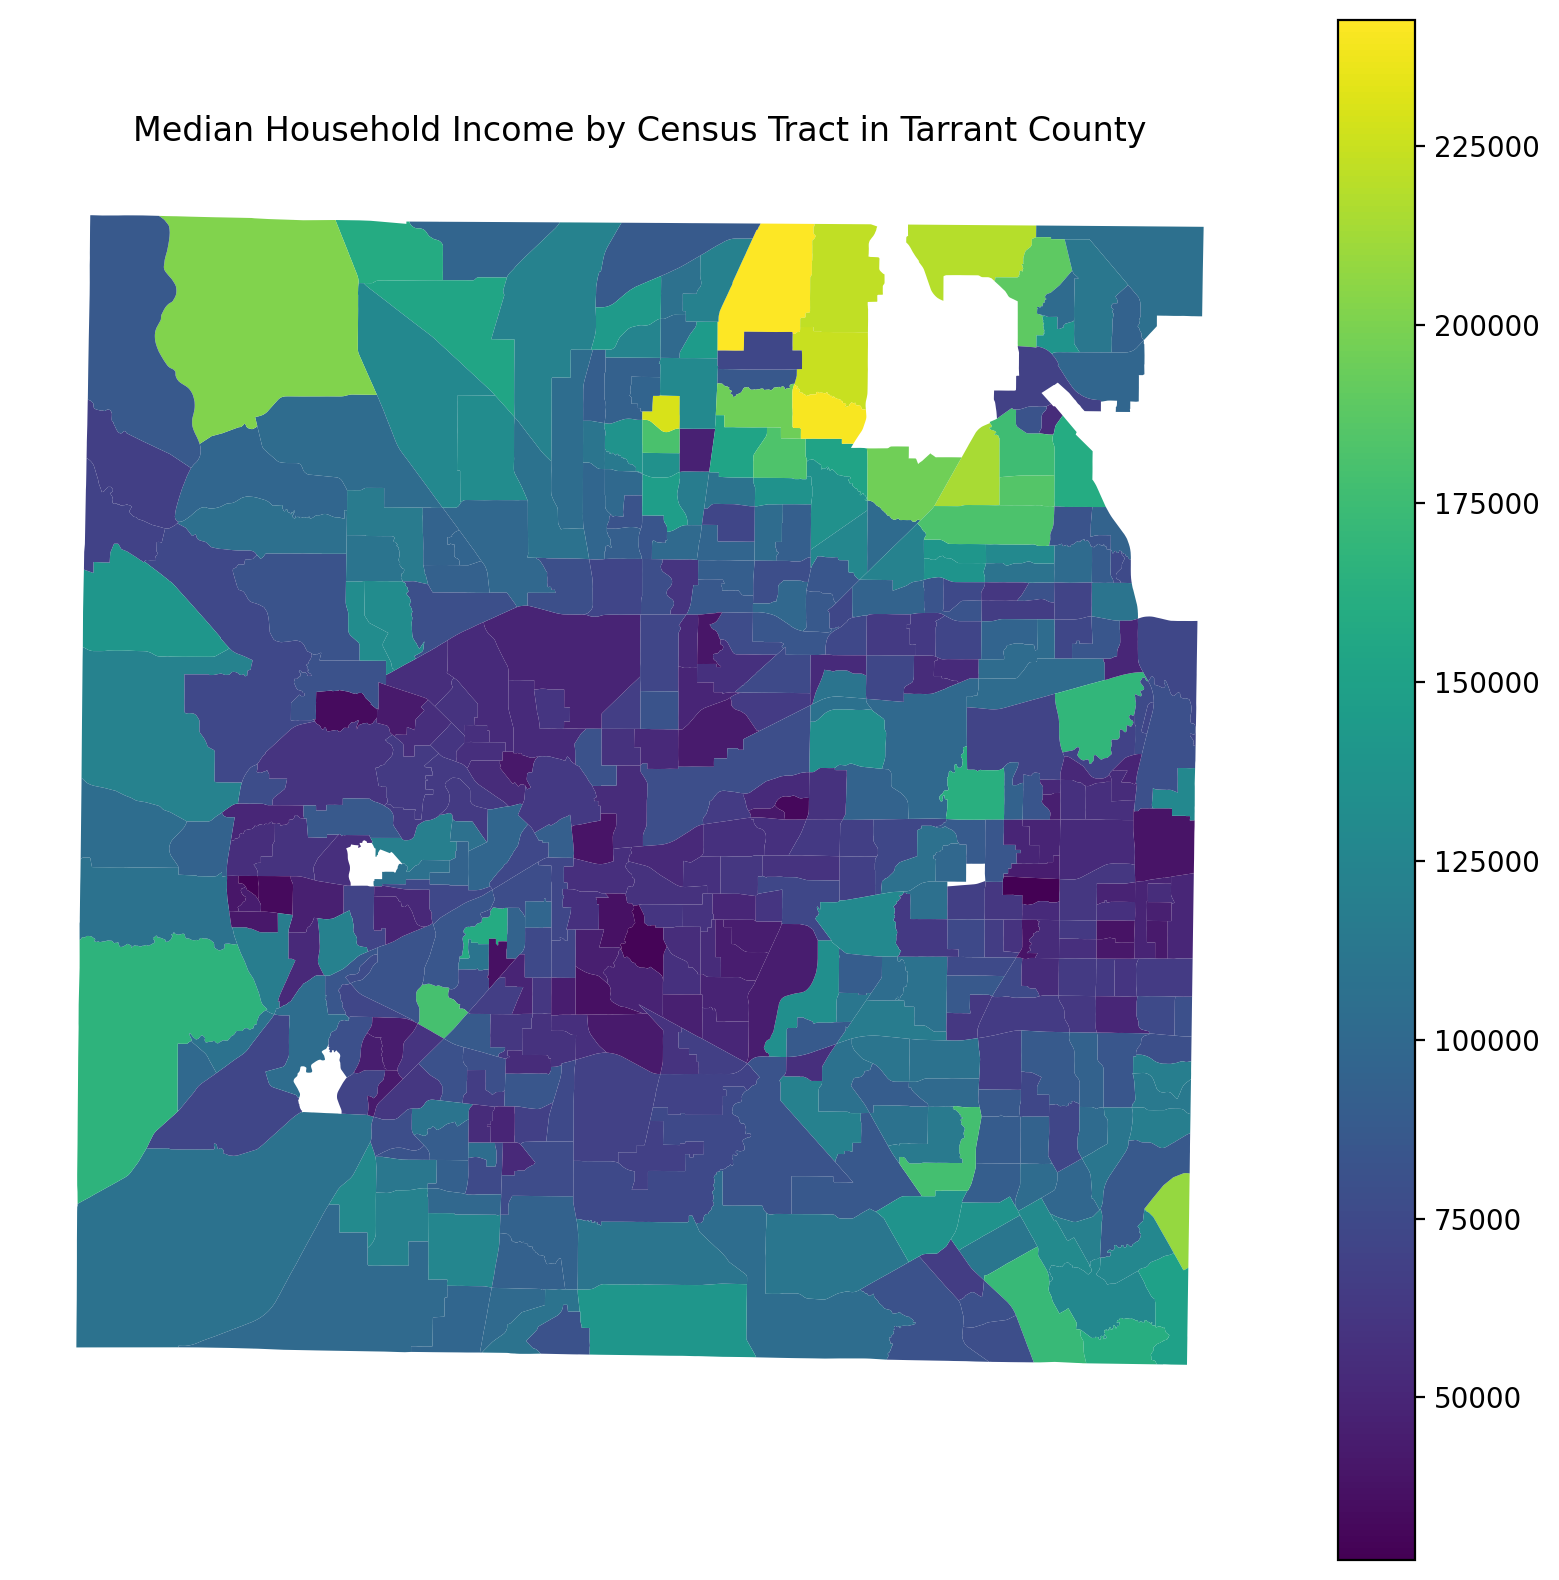

In [34]:
fig, ax = plt.subplots(figsize=(10,10))

merged.plot(
    column = "S1903_C03_001E",
    cmap = "viridis",
    legend = True,
    ax=ax
) 

plt.title("Median Household Income by Census Tract in Tarrant County")
plt.axis("off")
plt.show()


# 2. Mobility

## 2a. Dataframe

In [35]:
df = pd.read_csv('tarrantmobility_data.csv')
df

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48439100101,Census Tract 1001.01; Tarrant County; Texas,2497,374,1.7,1.5,8.8,4,46.2,8.9,...,26.6,25.3,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48439100102,Census Tract 1001.02; Tarrant County; Texas,2587,319,3.6,4.8,15,6.8,46.5,8.9,...,14.2,22.3,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48439100201,Census Tract 1002.01; Tarrant County; Texas,2165,419,5.3,4.6,8.9,5.5,57.1,9.6,...,64.3,38.9,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48439100202,Census Tract 1002.02; Tarrant County; Texas,2003,277,6.4,3.7,9.6,4.5,40.4,6.6,...,0,51,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1400000US48439123302,Census Tract 1233.02; Tarrant County; Texas,1391,251,0,3.5,4,3.8,51.2,9.5,...,0,13.8,(X),(X),(X),(X),(X),(X),(X),(X)
446,1400000US48439123500,Census Tract 1235; Tarrant County; Texas,1141,279,2.5,2.7,6,6.3,50,10.2,...,17.5,46.8,(X),(X),(X),(X),(X),(X),(X),(X)
447,1400000US48439123600,Census Tract 1236; Tarrant County; Texas,2177,355,0.6,0.9,15.2,9.1,72.1,8.1,...,0.8,7.7,(X),(X),(X),(X),(X),(X),(X),(X)
448,1400000US48439123700,Census Tract 1237; Tarrant County; Texas,2445,433,0.5,0.8,8.5,6.7,62.2,9.2,...,43.7,32.2,(X),(X),(X),(X),(X),(X),(X),(X)


## 2b. Mobility Merging

Subset of only Mobility

In [36]:
df_mobility = df[[
    "GEO_ID",
    "S0802_C01_094E"
]]

df_mobility

#merging
merged_2 = tarrant.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [37]:
merged_2["S0802_C01_094E"] = pd.to_numeric(
    merged_2["S0802_C01_094E"],
    errors="coerce"
)
#"S0802_C01_094E"

In [38]:
#for now, I am seeing looking at no vehicle
df_mobility = df[[
    "GEO_ID",
    "S0802_C01_094E"
]]
df_mobility

,GEO_ID,S0802_C01_094E
0,Geography,Estimate!!Total!!Workers 16 years and over in ...
1,1400000US48439100101,2.7
2,1400000US48439100102,0
3,1400000US48439100201,1.6
4,1400000US48439100202,0
...,...,...
445,1400000US48439123302,2
446,1400000US48439123500,2.5
447,1400000US48439123600,2.2
448,1400000US48439123700,3.9


## 3. Mapping

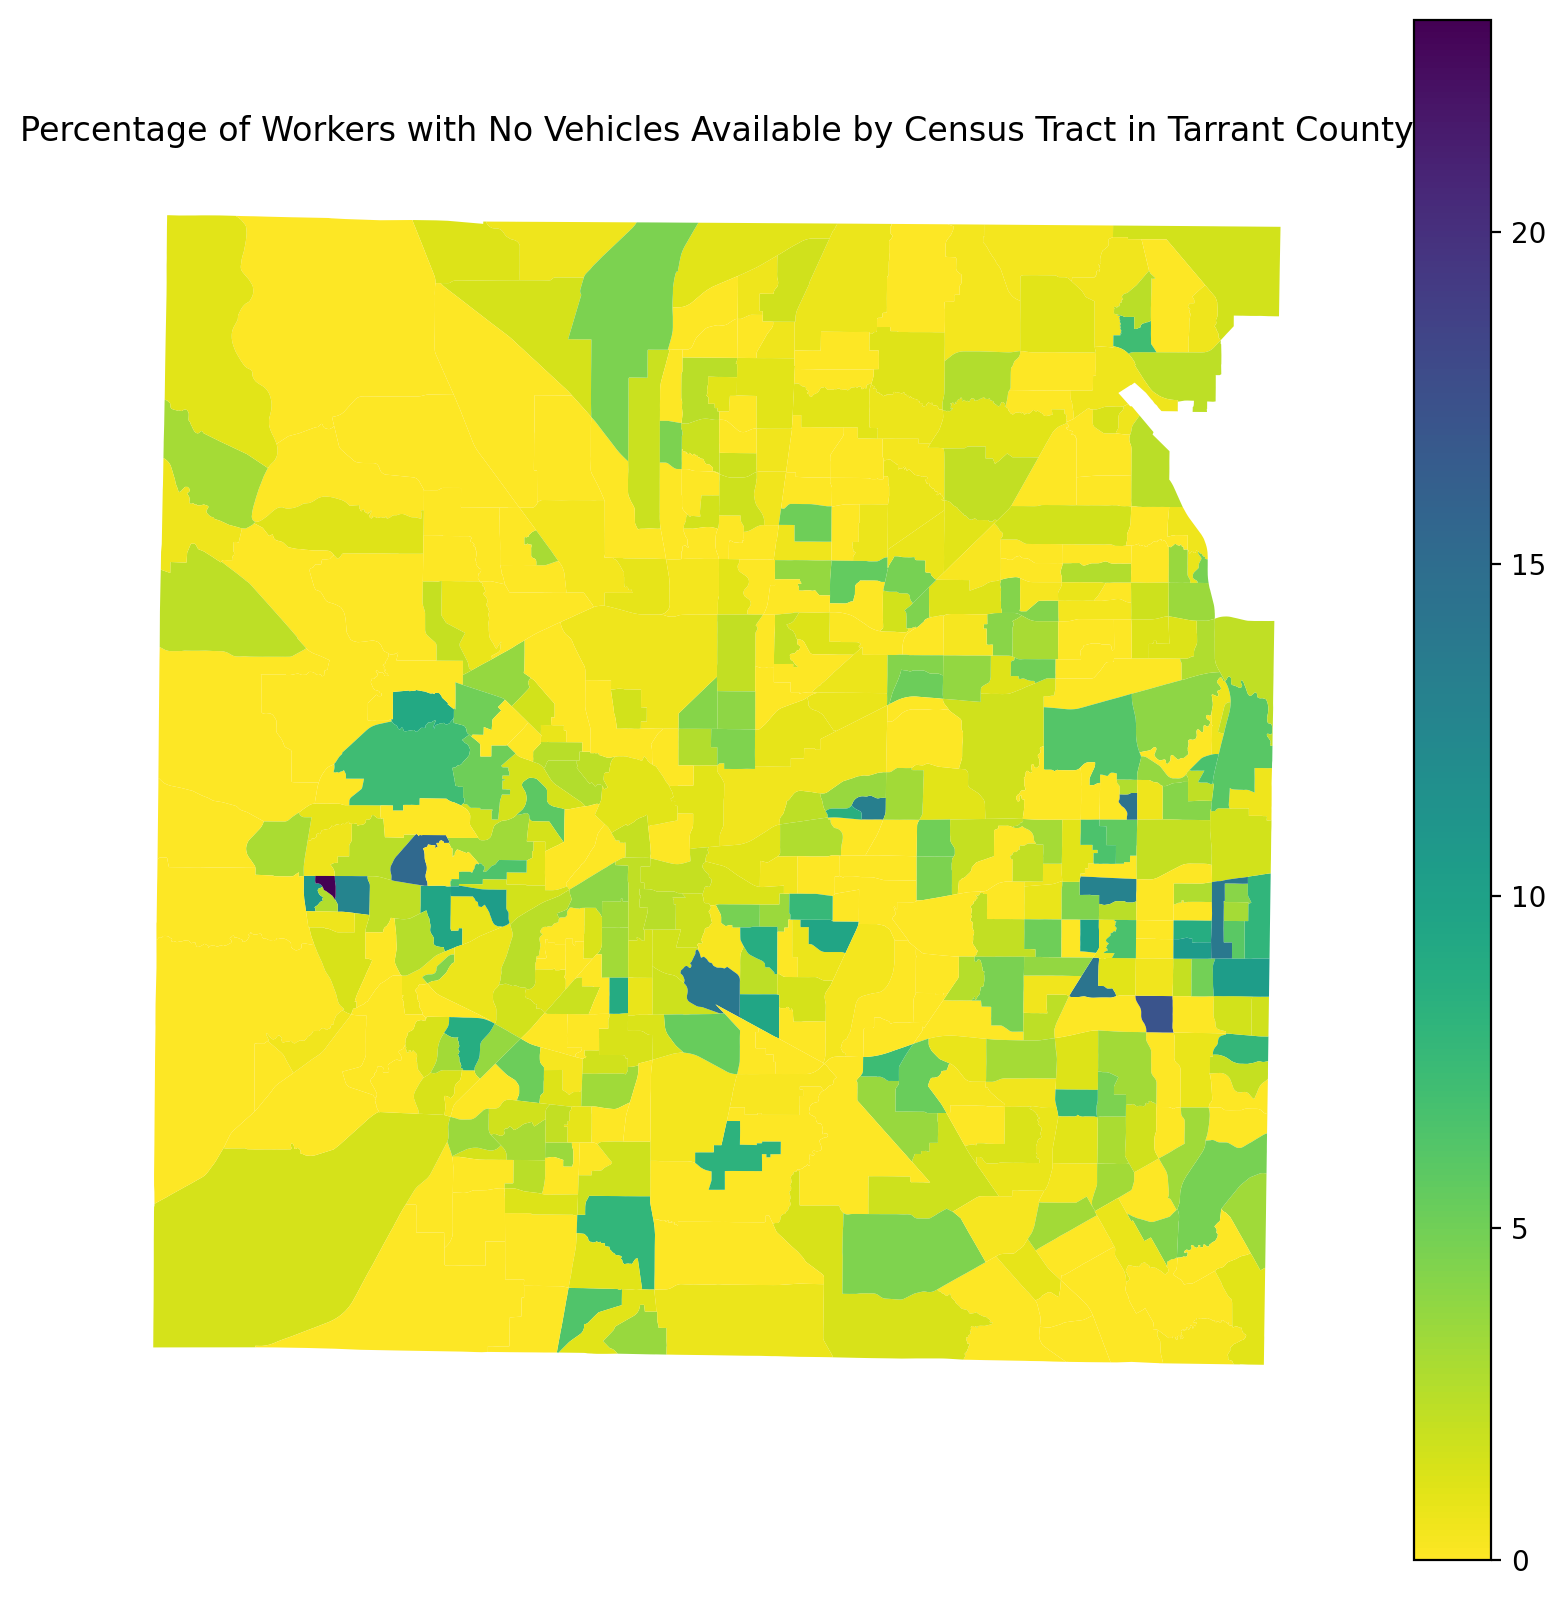

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_2.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Tarrant County")
plt.axis("off")
plt.show()

# 3. SNAP 
## 3a. Dataframe

In [47]:
df = pd.read_csv('tarrant_snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48439100101,Census Tract 1001.01; Tarrant County; Texas,1697,147,501,123,1196,186,694,176,...,(X),(X),(X),(X),16.7,9.8,22.9,10.7,60.4,13
2,1400000US48439100102,Census Tract 1001.02; Tarrant County; Texas,1914,192,431,83,1483,199,881,170,...,(X),(X),(X),(X),9.7,5.2,32.7,11.2,57.6,10.7
3,1400000US48439100201,Census Tract 1002.01; Tarrant County; Texas,1348,270,304,109,1044,292,644,147,...,(X),(X),(X),(X),3,4.2,35.4,14.1,61.6,13.9
4,1400000US48439100202,Census Tract 1002.02; Tarrant County; Texas,1395,154,512,156,883,136,751,173,...,(X),(X),(X),(X),12.3,11.5,25.1,11.3,62.6,13.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1400000US48439123302,Census Tract 1233.02; Tarrant County; Texas,1554,208,453,85,1101,218,409,117,...,(X),(X),(X),(X),12,9.2,32.8,16.3,55.2,17.3
446,1400000US48439123500,Census Tract 1235; Tarrant County; Texas,876,152,275,86,601,150,364,107,...,(X),(X),(X),(X),7.2,5.4,44.1,17.4,48.6,17
447,1400000US48439123600,Census Tract 1236; Tarrant County; Texas,1998,200,457,143,1541,220,324,147,...,(X),(X),(X),(X),11.9,11.6,18.1,14.6,70,17.1
448,1400000US48439123700,Census Tract 1237; Tarrant County; Texas,1936,258,496,164,1440,259,777,202,...,(X),(X),(X),(X),3.6,4.5,24.9,12.7,71.5,13.8


# 3. SNAP
## 3a. Dataset

In [ ]:
df = pd.read_csv('tarrant_snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48439100101,Census Tract 1001.01; Tarrant County; Texas,1697,147,501,123,1196,186,694,176,...,(X),(X),(X),(X),16.7,9.8,22.9,10.7,60.4,13
2,1400000US48439100102,Census Tract 1001.02; Tarrant County; Texas,1914,192,431,83,1483,199,881,170,...,(X),(X),(X),(X),9.7,5.2,32.7,11.2,57.6,10.7
3,1400000US48439100201,Census Tract 1002.01; Tarrant County; Texas,1348,270,304,109,1044,292,644,147,...,(X),(X),(X),(X),3,4.2,35.4,14.1,61.6,13.9
4,1400000US48439100202,Census Tract 1002.02; Tarrant County; Texas,1395,154,512,156,883,136,751,173,...,(X),(X),(X),(X),12.3,11.5,25.1,11.3,62.6,13.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1400000US48439123302,Census Tract 1233.02; Tarrant County; Texas,1554,208,453,85,1101,218,409,117,...,(X),(X),(X),(X),12,9.2,32.8,16.3,55.2,17.3
446,1400000US48439123500,Census Tract 1235; Tarrant County; Texas,876,152,275,86,601,150,364,107,...,(X),(X),(X),(X),7.2,5.4,44.1,17.4,48.6,17
447,1400000US48439123600,Census Tract 1236; Tarrant County; Texas,1998,200,457,143,1541,220,324,147,...,(X),(X),(X),(X),11.9,11.6,18.1,14.6,70,17.1
448,1400000US48439123700,Census Tract 1237; Tarrant County; Texas,1936,258,496,164,1440,259,777,202,...,(X),(X),(X),(X),3.6,4.5,24.9,12.7,71.5,13.8


## 3b. Merging

In [ ]:
df_snap= df[[
    "GEO_ID",
    "S2201_C04_001E"
]]

df_snap

merged = tarrant.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [54]:
merged["S2201_C04_001E"] = pd.to_numeric(
    merged["S2201_C04_001E"],
    errors="coerce"
)

## 3c. SNAP Mapping

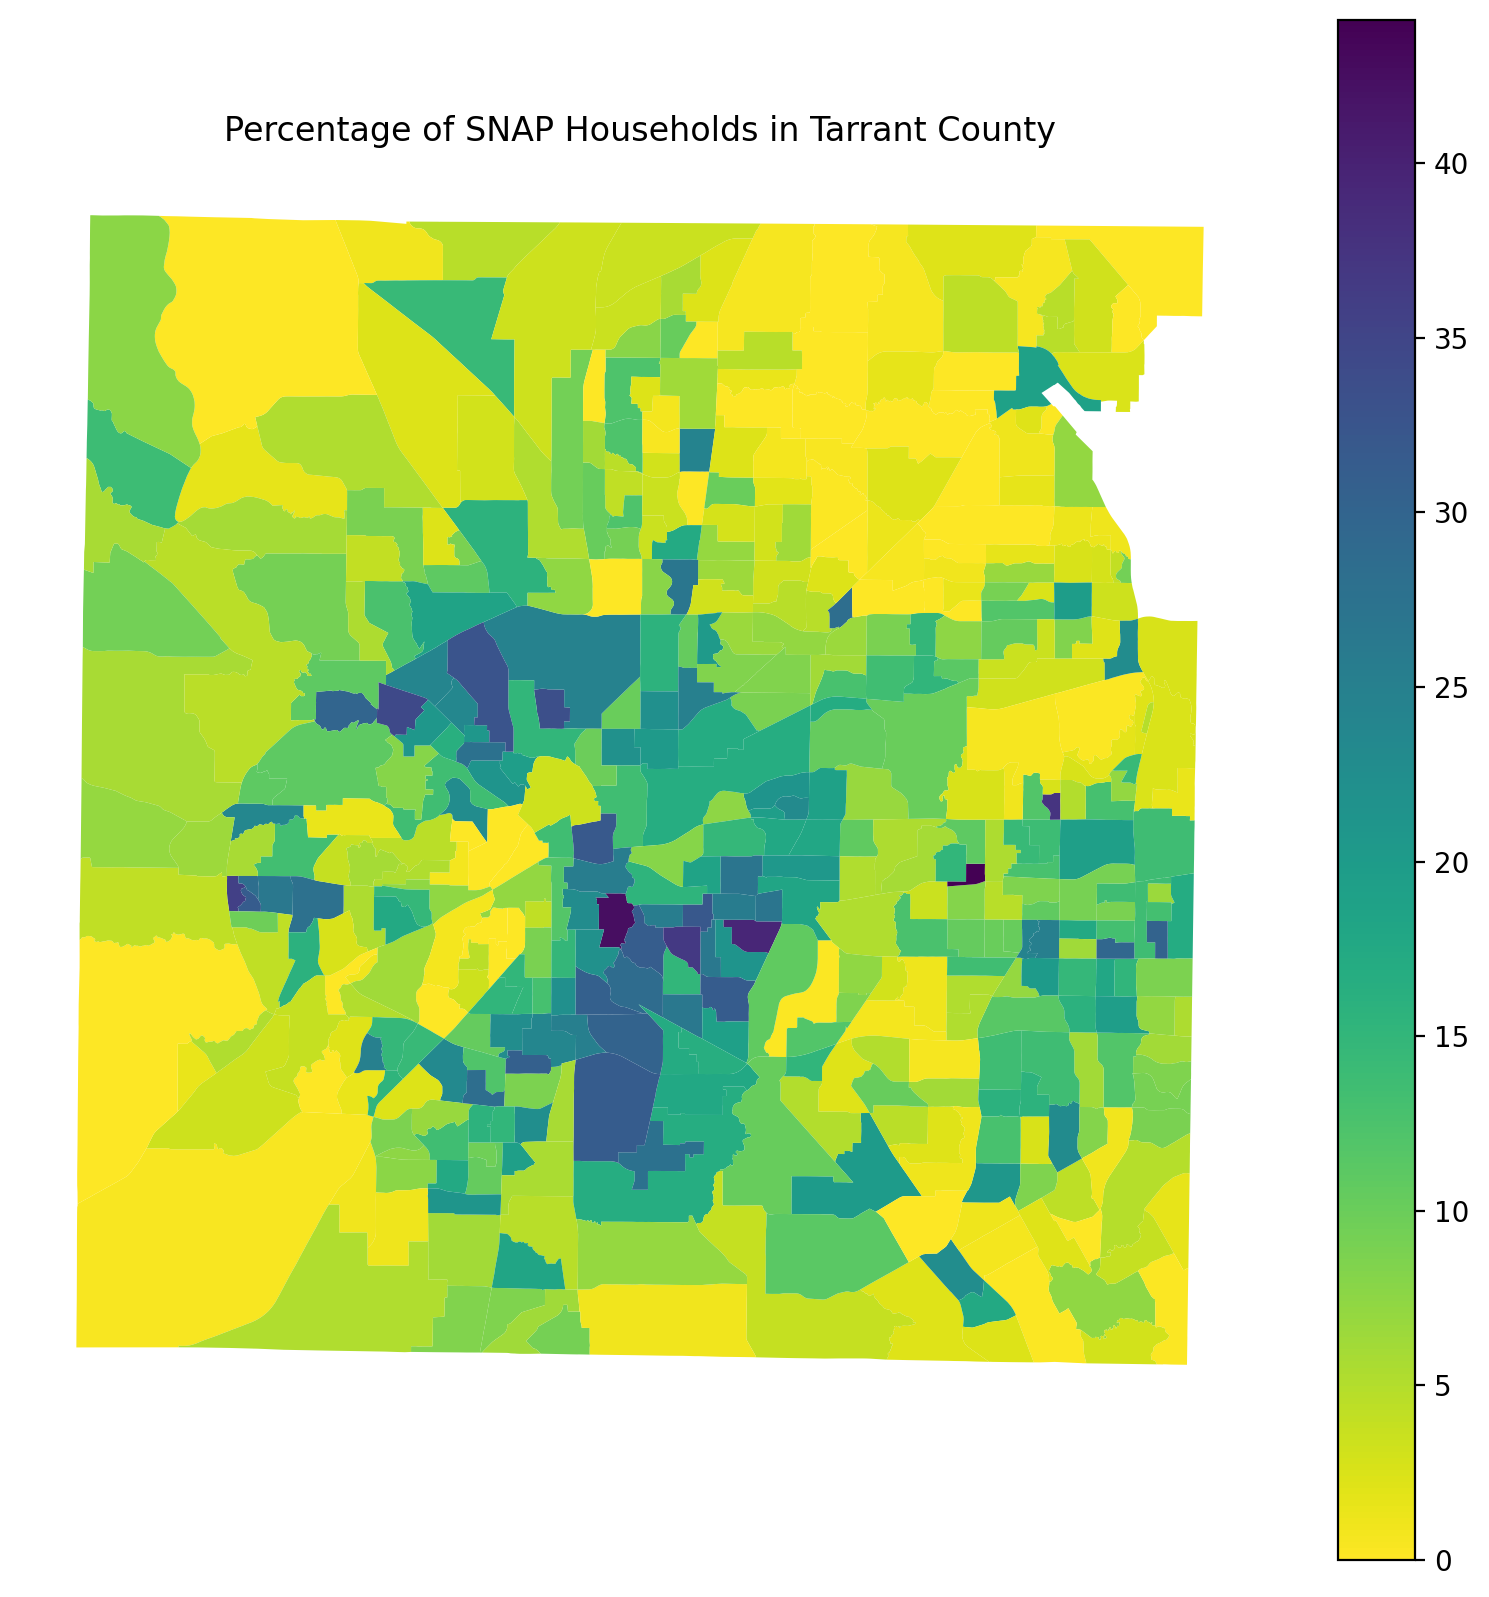

In [55]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S2201_C04_001E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households in Tarrant County")
plt.axis("off")
plt.show()